In [ ]:
!pip install PySUS
!pip install geopandas
!pip install geobr

In [ ]:
import pandas as pd
import geobr
import matplotlib.pyplot as plt
from pysus import SIM

##codigo para somente 1 estado do BRASil

sim = SIM().load()


arquivos = sim.get_files("CID10", uf="RJ", year="2022")

dados = sim.download(arquivos)
df = dados.to_dataframe()

coluna_codigos = df['CODMUNRES']
df['cod_cidade'] = coluna_codigos.astype(str)
df['cod_cidade'] = df['cod_cidade'].str.slice(0, 6)

contagem = df['cod_cidade'].value_counts()

mortes_cidade = contagem.reset_index()
mortes_cidade.columns = ['cod_cidade', 'qtd_mortes']

mapa = geobr.read_municipality(code_muni="RJ", year=2022)
texto_codigos = mapa['code_muni'].astype(str)
mapa['cod_6'] = texto_codigos.str.slice(0, 6)

mapa_final = mapa.merge(mortes_cidade, left_on="cod_6", right_on="cod_cidade", how="left")
mapa_final['qtd_mortes'] = mapa_final['qtd_mortes'].fillna(0)


mapa_final.plot(column='qtd_mortes',
                cmap='Reds',
                legend=True,
                figsize=(12, 8),
                edgecolor='black',
                linewidth=0.1)

plt.axis('off')
plt.show()

11928191it [00:00, 7658114070.73it/s]


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import geobr
import matplotlib.pyplot as plt
from pysus import SIM

##codigo feito para mais estados

sim = SIM().load()


arquivos = sim.get_files("CID10", uf="RJ"  ,year="2022")

dados = sim.download(arquivos)
print("0000000000000000000000")
temporario = []
for item in dados:
    df = item.to_dataframe()
    temporario.append(df)
df_brasil = pd.concat(temporario, ignore_index=True)

print("1111111111111111111111111111111")

coluna_codigos = df_brasil['CODMUNRES']
df_brasil['cod_cidade'] = coluna_codigos.astype(str)
df_brasil['cod_cidade'] = df_brasil['cod_cidade'].str.slice(0, 6)
print("2222222222222222222222")

contagem = df_brasil['cod_cidade'].value_counts()

print("33333333333333333333333333")
mortes_cidade = contagem.reset_index()

mortes_cidade.columns = ['cod_cidade', 'qtd_mortes']
print("44444444444444444444444444444")


rj = geobr.read_municipality(code_muni="all",year=2022)

mapa = pd.concat([  rj], ignore_index=True)
print("5555555555555555555555")

texto_codigos = mapa['code_muni'].astype(str)
mapa['cod_6'] = texto_codigos.str.slice(0, 6)

mapa_final = mapa.merge(mortes_cidade, left_on="cod_6", right_on="cod_cidade", how="left")
mapa_final['qtd_mortes'] = mapa_final['qtd_mortes'].fillna(0)
print("66666666666666666666666666666666")
#%%
mapa_final.plot(column='qtd_mortes',
                cmap='Reds',
                legend=True,
                figsize=(12, 8),
                edgecolor='black',
                linewidth=0.1)
print("777777777777777777777777777777")
plt.savefig('mapa_mortalidade_rj.png', dpi=300, bbox_inches='tight')


DORS2022.dbc:   4%|▍         | 336k/8.08M [00:02<00:22, 338kB/s]

KeyboardInterrupt: 

11928191it [00:00, 16593850488.91it/s]


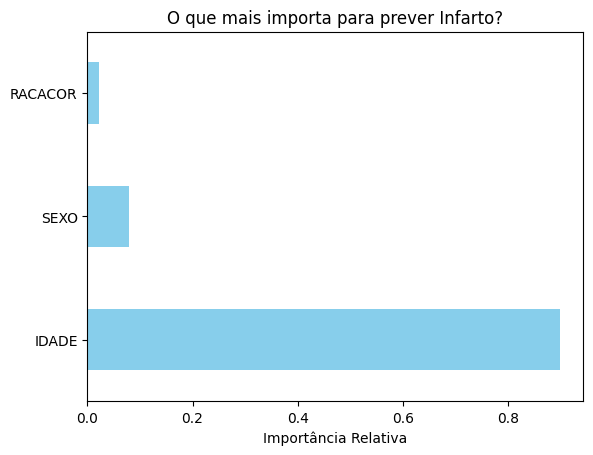

--- Resultado da IA (UERJ/FAPERJ) ---
Acurácia: 45.72%

Relatório de Performance:
              precision    recall  f1-score   support

           0       0.96      0.44      0.60     42139
           1       0.08      0.70      0.14      2778

    accuracy                           0.46     44917
   macro avg       0.52      0.57      0.37     44917
weighted avg       0.90      0.46      0.58     44917



In [ ]:

import pandas as pd
import numpy as np
from pysus import SIM
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

sim = SIM().load()
rj = sim.get_files("CID10", uf="RJ", year=2022)
download = sim.download(rj)
dataf_rj = download.to_dataframe()

dataf_rj['target'] = (dataf_rj['CAUSABAS'] == 'I219').astype(int)

cols_x = ["IDADE", "RACACOR", "SEXO"]
df_modelo = dataf_rj[cols_x + ['target']].copy()


for col in cols_x:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

df_modelo = df_modelo.dropna()

df_modelo['IDADE'] = df_modelo['IDADE'].apply(lambda x: x - 400 if x >= 400 else 0)


X = df_modelo[cols_x]
y = df_modelo['target']


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)


scaler = StandardScaler()
x_train_st = scaler.fit_transform(x_train)
x_test_st = scaler.transform(x_test)


model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=2)
model.fit(x_train_st, y_train)


y_pred = model.predict(x_test_st)

importancias = pd.Series(model.feature_importances_, index=X.columns)
importancias.nlargest(3).plot(kind='barh', color='skyblue')
plt.title('O que mais importa para prever Infarto?')
plt.xlabel('Importância Relativa')
plt.show()

print(f"--- Resultado da IA (UERJ/FAPERJ) ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nRelatório de Performance:")
print(classification_report(y_test, y_pred))